<a href="https://colab.research.google.com/github/alan-ajay/Condensed-Matter-Physics/blob/main/CMP_ASSIGNMENT_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Numerical Assignment 2 | Intro to CMP | 2026







 Let $V(x) = A \cos(\pi x/a) + (A/2)\cos(2\pi x/a) + (A/3)\cos(3\pi x/a)$ with $A = 3\text{ eV}$.

## Q1) Band Structure Plot: Plot the band structure in the first and second BZ for at least 5 bands.

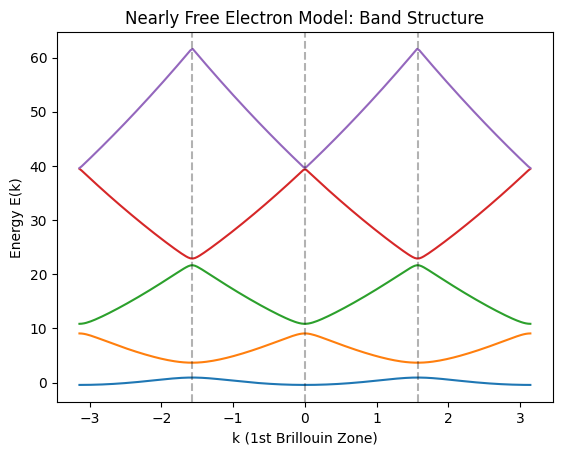

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#(hbar)**2/2m = 1
#a = 1 => g = pi*n

def Bloch_Hamiltonian(k, N, V, g=np.pi):
    H = np.zeros((N, N))
    G = g * (np.arange(N) - N // 2)

    for i in range(N):

        H[i, i] = (k - G[i])**2 + V[0]

        for j in range(1, len(V)):
            if i + j < N:
                H[i, i + j] = V[j]
                H[i + j, i] = np.conj(V[j])
    return H

def Plot_bands(N, V, num_bands=5, g = np.pi):
    k_vals = np.linspace(-np.pi, np.pi, 200)
    all_energies = []

    for k in k_vals:
        H = Bloch_Hamiltonian(k, N, V, g)
        eigenvalues = np.linalg.eigvalsh(H)
        all_energies.append(eigenvalues[:num_bands])

    energies = np.array(all_energies)
    for i in range(num_bands):
        plt.plot(k_vals, energies[:, i])

    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=g/2, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=-g/2, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("k (1st Brillouin Zone)")
    plt.ylabel("Energy E(k)")
    plt.title("Nearly Free Electron Model: Band Structure")
    plt.show()

V = [0, 3/2, 3/4, 1/2]
Plot_bands(15, V, 5)



## Q2) Density of States: Plot the corresponding density of states (DOS).



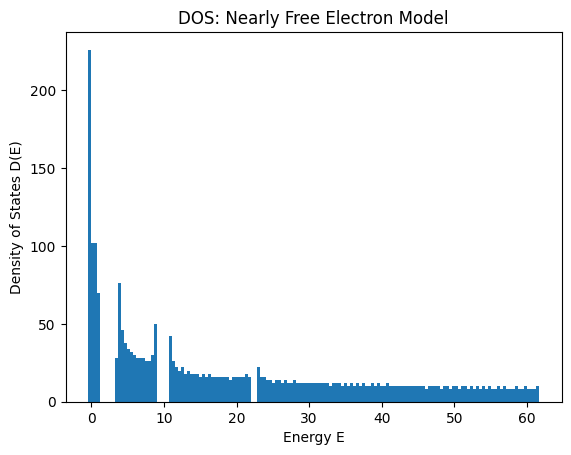

In [3]:
def BZ_eigenvalues(N, V):
    k_vals = np.linspace(-np.pi, np.pi, 500)
    all_energies = []
    for k in k_vals:
        H = Bloch_Hamiltonian(k, N, V)
        all_energies.append(np.linalg.eigvalsh(H)[:5]) # Top 5 bands
    return np.array(all_energies).flatten()

V = [0, 1.5, 0.75, 0.5]
energies = BZ_eigenvalues(21, V)

plt.hist(energies, bins=150)
plt.xlabel("Energy E")
plt.ylabel("Density of States D(E)")
plt.title("DOS: Nearly Free Electron Model")
plt.show()

### Q3) Convergence (Basis): Converge the band-structure w.r.t. the increasing number of Fourier basis used for expansion of the Bloch states. (In class we mostly wrote it for five plane wave basis $e^{iGx}$ with $G$ from $G_2$ to $G_{-2}$).

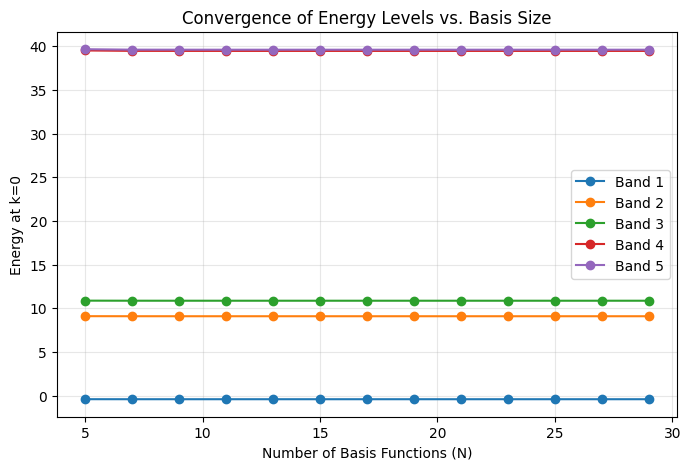

In [65]:
V = [0, 1.5, 0.75, 0.5]
n_range = np.arange(5, 31, 2) # Basis sizes from 5 to 29
band_convergence = []

# Check convergence at k = 0
for N in n_range:
    H = Bloch_Hamiltonian(0, N, V)
    eigenvalues = np.linalg.eigvalsh(H)
    band_convergence.append(eigenvalues[:5])

band_convergence = np.array(band_convergence)

plt.figure(figsize=(8, 5))
for i in range(5):
    plt.plot(n_range, band_convergence[:, i], 'o-', label=f'Band {i+1}')

plt.xlabel("Number of Basis Functions (N)")
plt.ylabel("Energy at k=0")
plt.title("Convergence of Energy Levels vs. Basis Size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Q4) Fermi Energy: Mark the Fermi energy if each unit cell has one valence electron.

###Converge the Fermi energy w.r.t. the increasing number of unit cells considered in the supercell (or in other words, a finer $k$-mesh).

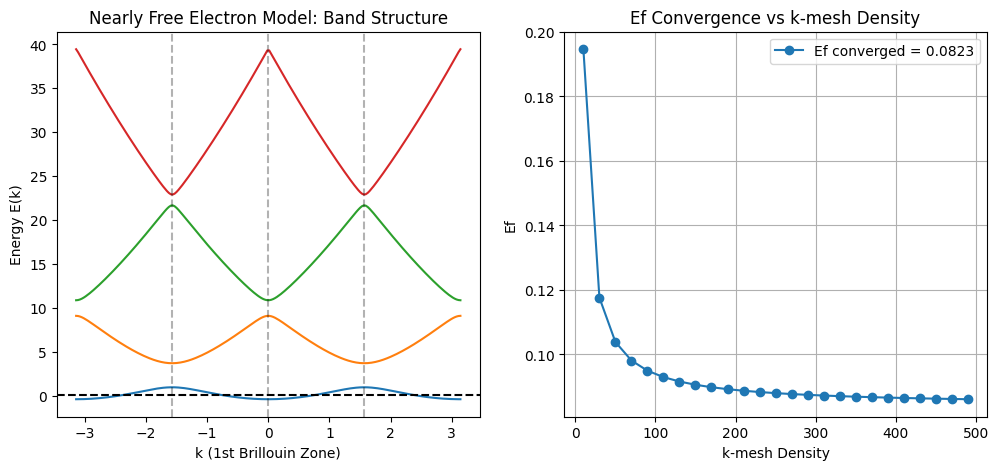

In [5]:
def find_fermi_energy(n, bz, V, N = 10):
  k_vals = np.linspace(-bz, bz, n)
  all_energies = []
  for k in k_vals:
    H = Bloch_Hamiltonian(k, N, V)
    all_energies.append(np.linalg.eigvalsh(H))
  energies = np.sort(np.array(all_energies).flatten())
  nf = int(n/2)
  return energies[nf-1]

V = [0, 1.5, 0.75, 0.5]
bz = np.pi/2

n_vals = np.arange(10, 501, 20)
Ef_vals = [find_fermi_energy(n, bz, V) for n in n_vals]
Ef_converged = find_fermi_energy(500, bz, V)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

k_vals = np.linspace(-np.pi, np.pi, 200)
all_energies = []

for k in k_vals:
    H = Bloch_Hamiltonian(k, 10, V)
    eigenvalues = np.linalg.eigvalsh(H)
    all_energies.append(eigenvalues[:4])

energies = np.array(all_energies)
for i in range(4):
    plt.plot(k_vals, energies[:, i])

plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=np.pi/2, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=-np.pi/2, color='k', linestyle='--', alpha=0.3)
plt.axhline(y=Ef_converged, color='black', linestyle='--', alpha=1)
plt.xlabel("k (1st Brillouin Zone)")
plt.ylabel("Energy E(k)")
plt.title("Nearly Free Electron Model: Band Structure")



plt.subplot(1, 2, 2)
plt.plot(n_vals, Ef_vals, 'o-', label=f'Ef converged = {Ef_converged:.4f}')
plt.title('Ef Convergence vs k-mesh Density')
plt.xlabel('k-mesh Density')
plt.ylabel('Ef')
plt.grid(True)
plt.legend()
plt.show()

## Q4) Additional Potential: Next, add the potential $2A \cos(0.5\pi x/a)$. Plot the resulting band structure and density of states

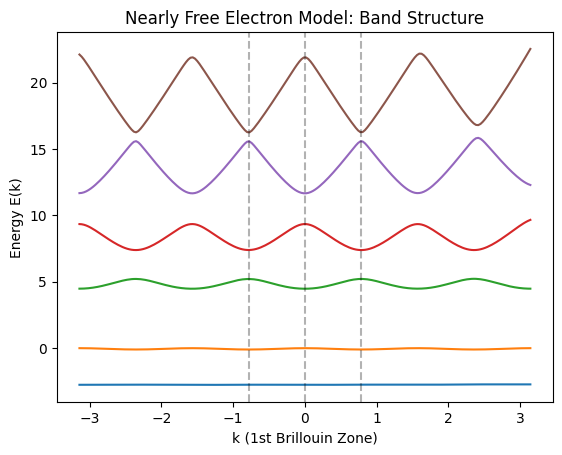

In [6]:
def Bloch_Hamiltonian(k, N, V, g=np.pi):
    H = np.zeros((N, N))
    G = g * (np.arange(N) - N // 2)

    for i in range(N):

        H[i, i] = (k - G[i])**2 + V[0]

        for j in range(1, len(V)):
            if i + j < N:
                H[i, i + j] = V[j]
                H[i + j, i] = np.conj(V[j])
    return H

def Plot_bands(N, V, num_bands=5, g = np.pi):
    k_vals = np.linspace(-np.pi, np.pi, 200)
    all_energies = []

    for k in k_vals:
        H = Bloch_Hamiltonian(k, N, V, g)
        eigenvalues = np.linalg.eigvalsh(H)
        all_energies.append(eigenvalues[:num_bands])

    energies = np.array(all_energies)
    for i in range(num_bands):
        plt.plot(k_vals, energies[:, i])

    plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=g/2, color='k', linestyle='--', alpha=0.3)
    plt.axvline(x=-g/2, color='k', linestyle='--', alpha=0.3)
    plt.xlabel("k (1st Brillouin Zone)")
    plt.ylabel("Energy E(k)")
    plt.title("Nearly Free Electron Model: Band Structure")
    plt.show()


V_new = [0, 3, 3/2, 0, 3/4, 0, 1/2]
Plot_bands(10, V_new, 6, g=np.pi/2)

## Q5) Total Energy: Compute total energy per unit cell by simply adding the energy of the occupied states and dividing it by $N_{BVK}$. Plot the energy per unit cell as a function of $A$.

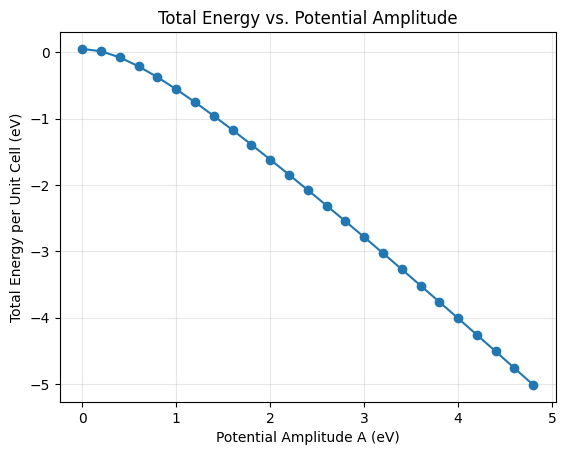

In [20]:
def Find_total_energy(n, bz, A, N = 10):
  V = [0, A, A/2, 0, A/4, 0, A/6]
  k_vals = np.linspace(-bz, bz, n)
  all_energies = []
  for k in k_vals:
    eigenvalues = np.linalg.eigvalsh(Bloch_Hamiltonian(k, N, V, g=bz))
    all_energies.append(eigenvalues)
  energies = np.sort(np.array(all_energies).flatten())
  #since each unit cells only contribute 1 electron
  total_energy = sum(2*energies[:n//2])
  return total_energy/n

# Execution
a_vals = np.arange(0, 5, 0.2)
energys = [Find_total_energy(100, np.pi/2, a) for a in a_vals]

plt.plot(a_vals, energys, 'o-')
plt.xlabel("Potential Amplitude A (eV)")
plt.ylabel("Total Energy per Unit Cell (eV)")
plt.title("Total Energy vs. Potential Amplitude")
plt.grid(True, alpha=0.3)
plt.show()

## Hartree approximation

One simple approach to improve on the computation of electronic structure within the single
particle picture is to solve the Poisson equation to obtain the potential due to the charge density of
the occupied states and add it to V(x) and iteratively converge the charge density.
You can easily do it by writing the Poisson equation in the Fourier basis.

Converged at iteration 37


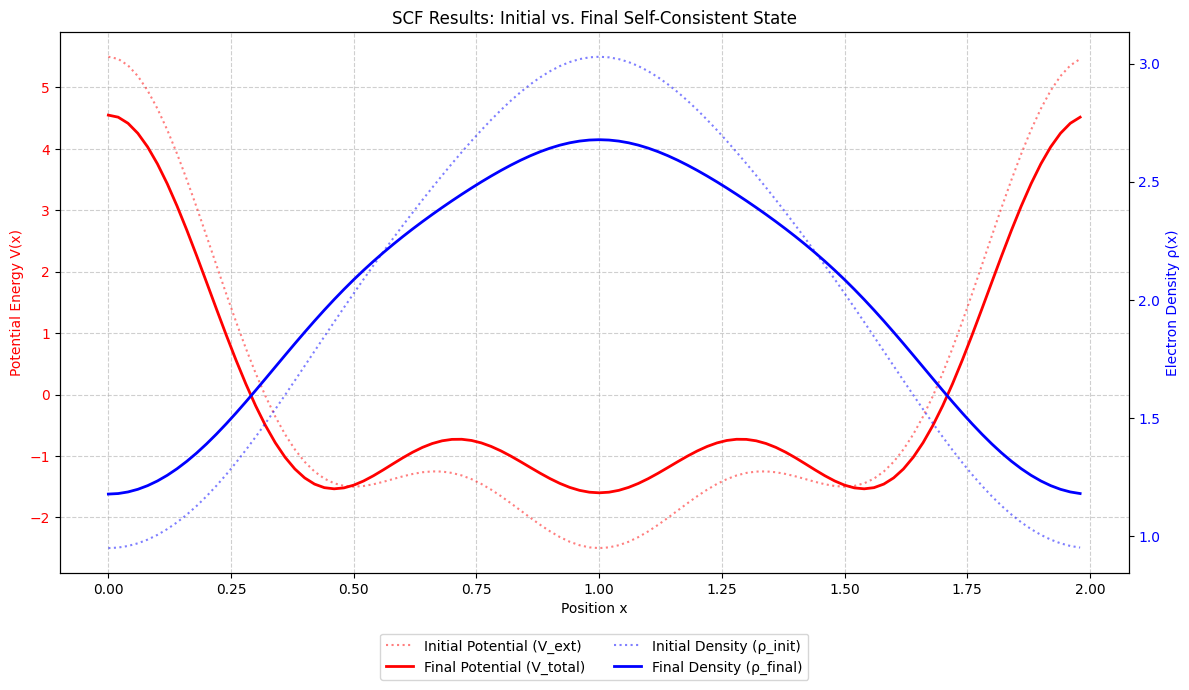

In [63]:


def Bloch_Hamiltonian(k, N, V, g=np.pi):
    H = np.zeros((N, N), dtype=complex)
    G = g * (np.arange(N) - N // 2)
    for i in range(N):
        H[i, i] = (k - G[i])**2 + V[0]
        for j in range(1, len(V)):
            if i + j < N:
                H[i, i + j] = V[j]
                H[i + j, i] = np.conj(V[j])
    return H

def find_rho(V, N=10, num_x=100):
    a = 1.0
    g = np.pi / a
    L = 2 * np.pi / g
    H = Bloch_Hamiltonian(0, N, V, g=g)
    eigenvalues, eigenvectors = np.linalg.eigh(H)
    c_G = eigenvectors[:, 0]
    c_G_shifted = np.fft.ifftshift(c_G)
    psi_x = np.fft.ifft(c_G_shifted, n=num_x) * num_x
    rho_x = 2 * np.abs(psi_x)**2
    x = np.linspace(0, L, num_x, endpoint=False)
    return x, rho_x

def find_V(rho_x, V_ext_len, num_x=100):
    L = 2.0
    g_base = 2 * np.pi / L
    rho_G_all = np.fft.rfft(rho_x) / num_x
    k_indices = np.arange(len(rho_G_all))
    G_grid = k_indices * g_base
    VH_G_all = rho_G_all * 0.0
    VH_G_all[1:] = (4 * np.pi * rho_G_all[1:]) / (G_grid[1:]**2)
    VH_list = np.real(VH_G_all[:V_ext_len])
    return VH_list

# 1. Setup Initial Conditions
V_ext = np.array([0, 1.5, 0.75, 0.5])
V_total = np.copy(V_ext)
V_hartree = np.zeros_like(V_ext)

# Capture INITIAL state for comparison
x_init, rho_init = find_rho(V_ext, N=100, num_x=100)
V_init_plot = np.zeros_like(x_init)
for j in range(len(V_ext)):
    V_init_plot += 2 * V_ext[j] * np.cos(j * np.pi * x_init)

# --- SCF LOOP parameters ---
mixing = 0.2  # Changed to 0.2 for stability; 1.0 often causes oscillations
tolerance = 1e-5
max_iter = 50

for i in range(max_iter):
    x, rho_x = find_rho(V_total, N=100, num_x=100)
    V_h_new = find_V(rho_x, len(V_ext), num_x=100)

    diff = np.linalg.norm(V_h_new - V_hartree)
    if diff < tolerance:
        print(f"Converged at iteration {i}")
        break

    V_hartree = (1 - mixing) * V_hartree + mixing * V_h_new
    V_total = V_ext + V_hartree

# --- Final Visualization ---
fig, ax1 = plt.subplots(figsize=(12, 7))

# 1. Plot Potentials (Left Axis)
ax1.set_xlabel('Position x')
ax1.set_ylabel('Potential Energy V(x)', color='red')
ax1.plot(x_init, V_init_plot, 'r:', alpha=0.5, label="Initial Potential (V_ext)")
V_final_plot = np.zeros_like(x)
for j in range(len(V_total)):
    V_final_plot += 2 * V_total[j] * np.cos(j * np.pi * x)
ax1.plot(x, V_final_plot, 'r-', linewidth=2, label="Final Potential (V_total)")
ax1.tick_params(axis='y', labelcolor='red')

# 2. Plot Densities (Right Axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Electron Density ρ(x)', color='blue')
ax2.plot(x_init, rho_init, 'b:', alpha=0.5, label="Initial Density (ρ_init)")
ax2.plot(x, rho_x, 'b-', linewidth=2, label="Final Density (ρ_final)")
ax2.tick_params(axis='y', labelcolor='blue')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)

plt.title("SCF Results: Initial vs. Final Self-Consistent State")
ax1.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()